# Building an Eval for an AI Shopping Assistant

In this build-along, you'll learn how to **build an eval** for an AI agent and use it to systematically find and fix problems.

`boutique` is a simple shopping assistant that looks up product prices and does math. It works... mostly. Your job is to figure out exactly where it breaks, why, and how to fix it.

In [1]:
!pip install -q anthropic --upgrade

from dotenv import load_dotenv

load_dotenv()

True

## Why Evals?

When you're building with Claude, "try it a few times and see if it works" isn't the best strategy. Vibes are definitely important, but Evals give you:

- **A baseline.** How good is the agent right now? Across what types of queries?
- **A feedback loop.** Change something (prompt, tool design, model), re-run, see if it actually helped and/or if there are any regressions.
- **Confidence.** Before shipping to a customer, you can point to numbers, not just vibes.

Today's build along:

1. **Meet the agent** and begin to notice what works and what doesn't
2. **Define eval tasks** that cover the agent's capabilities and edge cases
3. **Run the eval** and inspect results systematically
4. **Improve the agent** using eval results, then re-run to verify
5. **Add an LLM-as-judge grader** for queries that can't be checked with simple string matching

---

## Part 1: Meet the Agent

`boutique` is a simple single-turn agent. It has two tools:

| Tool | What it does |
|------|-------------|
| `get_product(product)` | Returns the price of an item from the catalog |
| `calculate(op, input1, input2)` | Basic math operations |

The agentic loop is simple:

```
User query → Claude decides what to do → Tool call (if needed) → Tool result → ... → Final answer
```

Skim through the code below. You might need to come back later to inspect:
- The **tool specs** (what Claude sees/knows about each tool)
- The **system prompt**
- The **tool implementations** (what actually happens when a tool is called)

In [24]:
import math
from anthropic import Anthropic
from anthropic.types import ToolUseBlock, TextBlock

# ── Config ────────────────────────────────────────────────────────────────────

MODEL = "claude-haiku-4-5-20251001"
MAX_TURNS = 10
SYSTEM_PROMPT = (
    "You are Boutique, a shopping assistant. You help customers find products, "
    "check prices, and calculate totals. Always use your tools to look up prices "
    "rather than guessing. If a product isn't found, suggest similar items from "
    "the catalog. Never do mental math, always use your calculate tool for any calculations. "
    "Only discuss topics related to shopping and products. If a question is unrelated to "
    "shopping, politely decline and offer to help with products or pricing instead."
)

client = Anthropic()

# ── Tool implementations ─────────────────────────────────────────────────────

def get_product(product: str):
    catalog = {
        "jeans": 49.99,
        "shirt": 29.99,
        "dress": 59.99,
        "jacket": 89.99,
        "sneakers": 74.99,
        "hat": 19.99,
        "socks": 9.99,
        "hoodie": 44.99,
        "shorts": 34.99,
        "t-shirt": 24.99,
        "sweater": 54.99,
        "belt": 24.99,
    }
    if product in catalog:
        return catalog[product]
    available = ", ".join(sorted(catalog.keys()))
    return f"Product '{product}' not found. Available products: {available}"


def calculate(op: str, input1: float, input2: float):
    match op:
        case "+": return input1 + input2
        case "-": return input1 - input2
        case "*": return input1 * input2
        case "/": return input1 / input2
        case "**": return input1 ** input2
        case _: return f"Unknown operator '{op}'. Valid operators: +, -, *, /, **"

TOOL_REGISTRY = {
    "get_product": get_product,
    "calculate": calculate,
}

# ── Tool specs (sent to Claude) ──────────────────────────────────────────────

GET_PRODUCT_SPEC = {
    "name": "get_product",
    "description": "Look up the price of a product from the store catalog. Returns the price as a number. If the product is not found, returns a message with the list of available products.",
    "input_schema": {
        "type": "object",
        "properties": {
            "product": {
                "type": "string",
                "description": "Product name, lowercase. Available products: jeans, shirt, dress, jacket, sneakers, hat, socks, hoodie, shorts, t-shirt, sweater, belt",
            },
        },
        "required": ["product"],
    },
}

CALCULATE_SPEC = {
    "name": "calculate",
    "description": "Perform a math operation on two numbers. Use this for any arithmetic instead of doing mental math.",
    "input_schema": {
        "type": "object",
        "properties": {
            "op": {
                "type": "string",
                "description": "The math operator to apply.",
                "enum": ["+", "-", "*", "/", "**"],
            },
            "input1": {
                "type": "number",
                "description": "The first operand.",
            },
            "input2": {
                "type": "number",
                "description": "The second operand.",
            },
        },
        "required": ["op", "input1", "input2"],
    },
}

ALL_TOOL_SPECS = [GET_PRODUCT_SPEC, CALCULATE_SPEC]

# ── Agent ─────────────────────────────────────────────────────────────────────

def call_claude(messages, tools, model=None):
    return client.messages.create(
        model=model or MODEL,
        system=SYSTEM_PROMPT,
        max_tokens = 1024,
        tools=tools,
        messages=messages,
    )


def execute_tool(name, inputs):
    try:
        return str(TOOL_REGISTRY[name](**inputs))
    except Exception as e:
        return f"Error: {e}"


def run_agent(prompt, eval_mode=False, model=None):
    messages = [{"role": "user", "content": prompt}]
    total_input_tokens = 0
    total_output_tokens = 0

    for _ in range(MAX_TURNS):
        response = call_claude(messages, tools=ALL_TOOL_SPECS, model=model)
        total_input_tokens += response.usage.input_tokens
        total_output_tokens += response.usage.output_tokens
        messages.append({"role": "assistant", "content": response.content})

        if response.stop_reason == "end_turn":
            break

        tool_calls = [block for block in response.content if isinstance(block, ToolUseBlock)]

        tool_results = []
        for tool_call in tool_calls:
            result = execute_tool(tool_call.name, tool_call.input)
            tool_results.append({
                "type": "tool_result",
                "tool_use_id": tool_call.id,
                "content": result,
            })

        messages.append({"role": "user", "content": tool_results})
    else:
        raise RuntimeError(f"Agent exceeded MAX_TURNS ({MAX_TURNS}) without finishing.")

    if eval_mode:
        return {
            "messages": messages,
            "usage": {"input_tokens": total_input_tokens, "output_tokens": total_output_tokens},
        }

    return "\n".join(block.text for block in response.content if isinstance(block, TextBlock))


print("boutique agent ready.")

boutique agent ready.


### Try It Out

Run the cell below to start an interactive session with the agent. Type queries and see how it responds. Type `quit` to stop.

Some queries to try:
- `How much do jeans cost?` (simple, should work)
- `Price of a t-shirt?` (will the hyphen trip it up?)
- `How much for shoes?` ("shoes" isn't in the catalog, but "sneakers" is)
- `3 shirts and 2 belts, what's my total?` (multi-tool: lookups + math)
- `What's 20% off a jacket?` (requires percentage math)
- `What do you sell?` (can it describe its own capabilities?)

In [13]:
from pprint import pprint

while True:
    query = input("\nYou: ")
    if not query.strip() or query.strip().lower() in ("quit", "exit", "q"):
        print("Session ended.")
        break
    print("\nBoutique:")
    pprint(run_agent(query, eval_mode=True))    


Boutique:
{'messages': [{'content': 'how much do jeans cost?', 'role': 'user'},
              {'content': [ToolUseBlock(id='toolu_01GcjvWmzqNdyoaiAMVBVzns', caller=DirectCaller(type='direct'), input={'product': 'jeans'}, name='get_product', type='tool_use')],
               'role': 'assistant'},
              {'content': [{'content': '49.99',
                            'tool_use_id': 'toolu_01GcjvWmzqNdyoaiAMVBVzns',
                            'type': 'tool_result'}],
               'role': 'user'},
              {'content': [TextBlock(citations=None, text='Jeans cost **$49.99**. Would you like to know about any other products or need help with anything else?', type='text')],
               'role': 'assistant'}],
 'usage': {'input_tokens': 1750, 'output_tokens': 85}}

Boutique:
{'messages': [{'content': 'price of a t-shirt?', 'role': 'user'},
              {'content': [ToolUseBlock(id='toolu_01CMyRsKTKygMLj4qj9u4vWb', caller=DirectCaller(type='direct'), input={'product': 't-shirt'},

---

## Part 2: The Eval Framework

An eval has three main components:

```
Tasks ──> Runner ──> Graders ──> Results
```

- **Tasks** define *what* to test: scenario, expected behavior, and how to grade it
- **Runner** orchestrates execution: sends scenarios' queries to the agent, collects transcripts, applies graders
- **Graders** check *whether* the agent did the right thing and return a score + reason

The runner and graders are defined in the next two cells. Run them both. You can quickly read through the code to understand how they work, but you won't need to modify them (yet).

### Available graders

| Grader | What it checks | Check format |
|--------|---------------|---------------|
| `response_contains` | Final text contains a string (case-insensitive) | `"49.99"` or `"jeans"` |
| `response_numeric` | Final text contains a number within tolerance | `{"value": 49.99, "tolerance": 0.05}` |
| `tool_use` | Agent called a specific tool with specific args | `{"tool_name": "get_product", "arguments": {"product": "jeans"}}` |

Each grader returns a binary score (0 = fail, 1 = pass) and a reason explaining why. A task passes only if **all checks from all graders** pass.

In [15]:
# ── Graders (just run this cell) ──────────────────────────────────────────────

import re

GRADER_REGISTRY = {}

def grader(fn):
    """Decorator that registers a grader by stripping the grade_ prefix from its name."""
    GRADER_REGISTRY[fn.__name__.removeprefix("grade_")] = fn
    return fn


@grader
def grade_response_contains(result, check, context=None):
    text = result["final_text"].lower()
    target = check.lower()
    if target in text:
        return {"score": 1.0, "reason": f"Found '{check}' in response"}
    return {"score": 0.0, "reason": f"'{check}' not found in response: {result['final_text'][:200]}"}


@grader
def grade_response_numeric(result, check, context=None):
    if isinstance(check, (int, float)):
        value, tolerance = float(check), 0.01
    else:
        value = float(check["value"])
        tolerance = float(check.get("tolerance", 0.01))

    numbers = re.findall(r"-?[\d,]+\.?\d*", result["final_text"])
    for num_str in numbers:
        try:
            num = float(num_str.replace(",", ""))
            if abs(num - value) <= tolerance:
                return {"score": 1.0, "reason": f"Found {num} (expected {value} +/- {tolerance})"}
        except ValueError:
            continue
    return {"score": 0.0, "reason": f"Expected {value} (+/- {tolerance}), found: {numbers[:10]}"}


@grader
def grade_tool_use(result, check, context=None):
    tool_name = check["tool_name"]
    expected_args = check.get("arguments", None)

    for call in result["tool_calls"]:
        if call["name"] != tool_name:
            continue
        if expected_args is None:
            return {"score": 1.0, "reason": f"Tool '{tool_name}' was called"}

        # Partial match: only check specified keys
        actual_args = call.get("arguments", {})
        match = all(
            (isinstance(v, str) and isinstance(actual_args.get(k), str) and v.lower() == actual_args[k].lower())
            or actual_args.get(k) == v
            for k, v in expected_args.items()
        )
        if match:
            return {"score": 1.0, "reason": f"Tool '{tool_name}' called with matching args: {expected_args}"}

    actual = [{"name": c["name"], "args": c.get("arguments", {})} for c in result["tool_calls"]]
    if expected_args:
        return {"score": 0.0, "reason": f"'{tool_name}' not called with {expected_args}. Actual: {actual}"}
    return {"score": 0.0, "reason": f"'{tool_name}' never called. Actual: {[c['name'] for c in result['tool_calls']]}"}


@grader
def grade_tool_efficiency(result, check, context=None):
    """Pass when the agent uses at most check['max_calls'] tool calls."""
    max_calls = check["max_calls"]
    actual = len(result["tool_calls"])
    if actual <= max_calls:
        return {"score": 1.0, "reason": f"Used {actual} tool call(s) — within limit of {max_calls}"}
    return {"score": 0.0, "reason": f"Used {actual} tool call(s) — exceeds limit of {max_calls}"}


print(f"Graders loaded: {list(GRADER_REGISTRY.keys())}")


Graders loaded: ['response_contains', 'response_numeric', 'tool_use', 'tool_efficiency']


In [16]:
# ── Eval Runner (just run this cell) ──────────────────────────────────────────

import json, os, time, traceback
from concurrent.futures import ThreadPoolExecutor, as_completed


def parse_transcript(messages):
    """Extract final_text and tool_calls from raw agent transcript."""
    final_text, tool_calls = "", []
    for msg in messages:
        if msg["role"] != "assistant":
            continue
        for block in msg["content"]:
            if isinstance(block, TextBlock):
                final_text = block.text
            elif isinstance(block, ToolUseBlock):
                tool_calls.append({"name": block.name, "arguments": block.input, "id": block.id})
    # Match tool results back to calls
    for msg in messages:
        if msg["role"] != "user" or not isinstance(msg["content"], list):
            continue
        for item in msg["content"]:
            if isinstance(item, dict) and item.get("type") == "tool_result":
                for call in tool_calls:
                    if call["id"] == item["tool_use_id"]:
                        call["result"] = item.get("content", "")
                        break
    return {"final_text": final_text, "tool_calls": tool_calls, "messages": messages}


def run_single_task(agent_fn, task, model=None):
    """Run one task, apply graders, return result with grades + metrics."""
    start = time.time()
    try:
        raw = agent_fn(task["query"], eval_mode=True, model=model)
    except Exception:
        return {
            "task_id": task["id"], "task_description": task.get("description", ""),
            "query": task["query"], "category": task.get("category", ""),
            "error": traceback.format_exc(), "passed": False, "grades": [],
            "metrics": {"time": time.time() - start},
        }

    elapsed = time.time() - start
    result = parse_transcript(raw["messages"])
    usage = raw.get("usage", {})
    turns = sum(1 for m in raw["messages"] if m["role"] == "assistant")
    metrics = {
        "time": round(elapsed, 3), "tool_calls": len(result["tool_calls"]),
        "turns": turns, "input_tokens": usage.get("input_tokens", 0),
        "output_tokens": usage.get("output_tokens", 0),
    }

    grades = []
    context = {"query": task["query"], "task_id": task["id"], "model": model}
    for grader in task.get("graders", []):
        grader_fn = GRADER_REGISTRY.get(grader["type"])
        if grader_fn is None:
            grades.append({"type": grader["type"], "check": None, "score": 0.0, "reason": f"Unknown grader: {grader['type']}"})
            continue
        for check in grader.get("checks", []):
            grade = grader_fn(result, check, context)
            grades.append({"type": grader["type"], "check": check, "score": grade["score"], "reason": grade["reason"]})

    passed = all(g["score"] == 1.0 for g in grades) if grades else False

    return {
        "task_id": task["id"], "task_description": task.get("description", ""),
        "query": task["query"], "category": task.get("category", ""),
        "passed": passed, "grades": grades, "metrics": metrics,
        "final_text": result["final_text"],
        "transcript": [
            block.model_dump() if hasattr(block, "model_dump") else block
            for msg in raw["messages"]
            for block in (msg["content"] if isinstance(msg["content"], list) else [msg["content"]])
        ],
    }


def run_eval(agent_fn, tasks, model=None, num_runs=1, max_workers=5):
    """Run the full eval suite. Returns structured results."""
    validate_tasks(tasks)
    all_runs = []
    for _ in range(num_runs):
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {executor.submit(run_single_task, agent_fn, t, model): t for t in tasks}
            run_results = [f.result() for f in as_completed(futures)]
        task_order = {t["id"]: i for i, t in enumerate(tasks)}
        run_results.sort(key=lambda r: task_order.get(r["task_id"], 999))
        all_runs.append(run_results)
    return {"runs": all_runs, "config": {"model": model, "num_runs": num_runs, "num_tasks": len(tasks)}}


def save_results(results, directory="eval_results"):
    """Save eval results to a JSON file."""
    os.makedirs(directory, exist_ok=True)
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    model_name = results["config"].get("model") or "default"
    model_short = model_name.split("-")[1] if "-" in str(model_name) else model_name
    filename = f"{directory}/eval_{model_short}_{timestamp}.json"
    with open(filename, "w") as f:
        json.dump(results, f, indent=2, default=str)
    print(f"Results saved to {filename}")
    return filename


def print_summary(results):
    """Print formatted eval results."""
    config = results["config"]
    print(f"{'=' * 60}")
    print(f"EVAL RESULTS: {config['num_tasks']} tasks, {config['num_runs']} run(s)")
    if config.get("model"): print(f"Model: {config['model']}")
    print(f"{'=' * 60}\n")

    for run_idx, run in enumerate(results["runs"]):
        if config["num_runs"] > 1: print(f"--- Run {run_idx + 1} ---")
        passed = sum(1 for r in run if r["passed"])
        total = len(run)
        print(f"Overall: {passed}/{total} passed ({passed/total*100:.0f}%)\n")

        # Per-category breakdown
        categories = {}
        for r in run:
            cat = r.get("category", "uncategorized")
            categories.setdefault(cat, {"passed": 0, "total": 0})
            categories[cat]["total"] += 1
            if r["passed"]: categories[cat]["passed"] += 1
        if len(categories) > 1:
            print("By category:")
            for cat, c in sorted(categories.items()):
                print(f"  {cat}: {c['passed']}/{c['total']} ({c['passed']/c['total']*100:.0f}%)")
            print()

        # Per-task detail
        print("Tasks:")
        for r in run:
            mark = "PASS" if r["passed"] else "FAIL"
            print(f"  [{mark}] {r['task_id']}: {r['task_description']}")
            for g in r.get("grades", []):
                print(f"    {'+' if g['score'] == 1.0 else '-'} {g['type']}: {g['reason'][:120]}")
            if r.get("error"): print(f"    Error: {r['error'][:200]}")

        # Aggregate metrics
        ok = [r for r in run if not r.get("error")]
        if ok:
            print(f"\nMetrics (avg): {sum(r['metrics']['time'] for r in ok)/len(ok):.2f}s, "
                  f"{sum(r['metrics']['tool_calls'] for r in ok)/len(ok):.1f} tool calls, "
                  f"{sum(r['metrics']['turns'] for r in ok)/len(ok):.1f} turns")
            print(f"Tokens: {sum(r['metrics']['input_tokens'] for r in ok):,} in, "
                  f"{sum(r['metrics']['output_tokens'] for r in ok):,} out")
        print()


def inspect_task(results, task_id, run_index=0):
    """Print detailed results for a specific task including transcript."""
    run = results["runs"][run_index]
    r = next((r for r in run if r["task_id"] == task_id), None)
    if r is None:
        print(f"Task '{task_id}' not found"); return

    print(f"[{'PASS' if r['passed'] else 'FAIL'}] {r['task_id']}: {r['task_description']}")
    print(f"Query: {r['query']}")
    print(f"Response: {r.get('final_text', 'N/A')}\n")
    if r.get("error"): print(f"ERROR:\n{r['error']}"); return

    print("Grades:")
    for g in r["grades"]:
        print(f"  {'+' if g['score'] == 1.0 else '-'} {g['type']}: {g['reason']}")
    print(f"\nMetrics: {r['metrics']}")

    print("\nTranscript:")
    for item in r.get("transcript", []):
        if isinstance(item, dict):
            t = item.get("type", "?")
            if t == "text": print(f"  [text] {item.get('text', '')[:300]}")
            elif t == "tool_use": print(f"  [tool_use] {item.get('name', '?')}({item.get('input', {})})")
            elif t == "tool_result": print(f"  [tool_result] {str(item.get('content', ''))[:200]}")
            else: print(f"  [{t}] {str(item)[:200]}")
        else: print(f"  {str(item)[:200]}")



def validate_tasks(tasks):
    """Validate task list before running eval. Raises ValueError on any problem."""
    REQUIRED_TASK_FIELDS = {"id", "description", "query", "category", "graders"}
    REQUIRED_GRADER_FIELDS = {"type", "checks"}
    errors = []
    seen_ids = {}

    for i, task in enumerate(tasks):
        loc = f"tasks[{i}]"

        missing = REQUIRED_TASK_FIELDS - task.keys()
        if missing:
            errors.append(f"{loc}: missing fields {sorted(missing)}")
            continue  # can't validate further without required fields

        task_id = task["id"]
        if task_id in seen_ids:
            errors.append(f"{loc}: duplicate id '{task_id}' (first seen at tasks[{seen_ids[task_id]}])")
        seen_ids[task_id] = i

        if not isinstance(task["graders"], list) or not task["graders"]:
            errors.append(f"{loc} ({task_id}): 'graders' must be a non-empty list")
            continue

        for j, grader in enumerate(task["graders"]):
            gloc = f"{loc}.graders[{j}]"
            missing = REQUIRED_GRADER_FIELDS - grader.keys()
            if missing:
                errors.append(f"{gloc}: missing fields {sorted(missing)}")
                continue
            if grader["type"] not in GRADER_REGISTRY:
                errors.append(f"{gloc}: unknown grader type '{grader['type']}' (known: {sorted(GRADER_REGISTRY)})")
            if not isinstance(grader["checks"], list) or not grader["checks"]:
                errors.append(f"{gloc}: 'checks' must be a non-empty list")

    if errors:
        raise ValueError("Task validation failed:\n" + "\n".join(f"  - {e}" for e in errors))
    print(f"validate_tasks: {len(tasks)} tasks OK")


print("Eval framework ready.")

Eval framework ready.


### Design decisions worth noting

If you read through the grader and runner code above, a few choices stand out:

- **Registry dict, not if/elif.** Graders are looked up by type name in `GRADER_REGISTRY`, a plain dict. Adding a new grader type is one function + one dict entry, no need to touch a dispatch chain. This is the pattern most eval frameworks use.

- **The runner doesn't print.** `run_eval()` returns a data structure; `print_summary()` is a separate function. This keeps the runner testable and reusable. You could swap in a different display, save to JSON, or feed results into a dashboard without changing the runner.

- **Agent as parameter.** The runner takes `agent_fn` as an argument instead of importing the agent directly. This makes it easy to test with a mock, swap in a different agent, or wrap the agent with instrumentation.

- **Runner owns transcript parsing.** The agent returns raw messages; the runner extracts `final_text`, `tool_calls`, etc. This avoids duplicate extraction logic and keeps the agent clean. It doesn't need to know how it will be evaluated.

- **Failed runs ≠ failed tasks.** If the agent throws an exception (API error, timeout), that's a *failed run*, captured in the `error` field. Grading is skipped. If the agent returns the wrong answer, that's a *failed task* : graders run normally and report what went wrong. The distinction matters. Errors mean the infrastructure broke; failures mean the agent gave the wrong answer.

- **Concurrency.** Tasks run in parallel using `ThreadPoolExecutor`, the standard pattern for I/O-bound API calls. Unbounded parallelism would hit rate limits. If your agent used the async `AsyncAnthropic` client instead, you'd replace this with `asyncio.gather()`.

---

## Part 3: Define Your Eval Tasks

### Task schema

Each task is a Python dict with these fields:

```python
{
    "id": "unique_task_id",             # Short, descriptive identifier
    "description": "What this tests",    # Human-readable description
    "query": "The user's question",      # What gets sent to the agent
    "category": "product_lookup",        # For grouping results
    "graders": [                          # List of grader declarations
        {
            "type": "response_contains",  # Which grader to use
            "checks": ["49.99"],          # What to check (one or more)
        },
    ],
}
```

### Worked example

Here's a task that checks whether the agent can look up the price of jeans:

```python
{
    "id": "price_jeans",
    "description": "Direct price lookup for jeans",
    "query": "How much do jeans cost?",
    "category": "product_lookup",
    "graders": [
        {"type": "response_contains", "checks": ["49.99"]},
        {"type": "tool_use", "checks": [{"tool_name": "get_product", "arguments": {"product": "jeans"}}]},
    ],
}
```

This task uses two graders:
1. `response_contains` checks that the final answer mentions "49.99"
2. `tool_use` checks that the agent actually called `get_product` with `product="jeans"` (didn't hallucinate the price)

### A note on `tool_use` grader brittleness

Tool use checks should verify that the agent *grounded its answer in tools* (didn't hallucinate a price or do mental math), not enforce a rigid call sequence. If the agent reaches the correct answer via a valid but unexpected path, that's fine.

Checking `{"tool_name": "get_product"}` (no arguments) verifies the agent used the tool at all. Checking `{"tool_name": "get_product", "arguments": {"product": "jeans"}}` verifies the exact argument. Only do this when the argument value is the thing you're testing (e.g., synonym resolution).

### Your turn

The jeans task is given as a reference. Now build tasks for these five example queries:

1. `"Price of a t-shirt?"` - Will the agent handle the hyphen correctly? What argument should it pass to `get_product`?
2. `"How much for shoes?"` - "shoes" isn't in the catalog. What *should* happen here, and how do you grade it?
3. `"3 shirts and 2 belts, what's my total?"` - Multiple product lookups plus a calculation. What's the expected total?
4. `"What's 20% off a jacket?"` - Needs both a product lookup and a calculation. What number should you check for?
5. `"What do you sell?"` - Open-ended. Can you grade this with the graders you have? (Hint: come back to this one after Part 6.)

For each query, think about:
- Which category does it belong to?
- Which graders make sense? What checks?
- What's the expected correct answer?
- Is a `tool_use` check needed, or is checking the response enough?

In [17]:
tasks = [
    # ── Reference task ─────────────────────────────────────────────────────
    {
        "id": "price_jeans",
        "description": "Direct price lookup for jeans",
        "query": "How much do jeans cost?",
        "category": "product_lookup",
        "graders": [
            {"type": "response_contains", "checks": ["49.99"]},
            {"type": "tool_use", "checks": [{"tool_name": "get_product", "arguments": {"product": "jeans"}}]},
        ],
    },

    # ── 1. Hyphenated product name ─────────────────────────────────────────
    # "t-shirt" is in the catalog; tests whether the agent passes the exact
    # hyphenated key rather than "tshirt" or "t shirt" (which would KeyError).
    {
        "id": "price_tshirt",
        "description": "Price lookup with hyphenated product name",
        "query": "Price of a t-shirt?",
        "category": "product_lookup",
        "graders": [
            {"type": "response_contains", "checks": ["24.99"]},
            {"type": "tool_use", "checks": [{"tool_name": "get_product", "arguments": {"product": "t-shirt"}}]},
        ],
    },

    # ── 2. Synonym / not-in-catalog ────────────────────────────────────────
    # "shoes" is NOT in the catalog; "sneakers" is (74.99). The agent should
    # attempt the tool and suggest the closest match rather than hallucinating.
    {
        "id": "price_shoes_synonym",
        "description": "Synonym query: 'shoes' not in catalog, 'sneakers' is",
        "query": "How much for shoes?",
        "category": "product_lookup",
        "graders": [
            {"type": "tool_use", "checks": [{"tool_name": "get_product"}]},
            {"type": "response_contains", "checks": ["sneakers"]},
        ],
    },

    # ── 3. Multi-tool: lookups + calculation ───────────────────────────────
    # shirt=29.99, belt=24.99; 3*29.99=89.97, 2*24.99=49.98, total=139.95
    {
        "id": "total_shirts_belts",
        "description": "Multi-item total requiring product lookups + calculation",
        "query": "3 shirts and 2 belts, what's my total?",
        "category": "multi_tool",
        "graders": [
            {"type": "response_numeric", "checks": [{"value": 139.95, "tolerance": 0.10}]},
            {"type": "tool_use", "checks": [
                {"tool_name": "get_product"},
                {"tool_name": "calculate", "arguments": {"op": "*"}},
                {"tool_name": "calculate", "arguments": {"op": "+"}},
            ]},
        ],
    },

    # ── 4. Percentage discount ─────────────────────────────────────────────
    # jacket=89.99; 20% off → 89.99 * 0.80 = 71.992 ≈ 71.99
    {
        "id": "discount_jacket",
        "description": "Calculate 20% off a jacket (lookup + percentage math)",
        "query": "What's 20% off a jacket?",
        "category": "calculation",
        "graders": [
            {"type": "response_numeric", "checks": [{"value": 71.99, "tolerance": 0.10}]},
            {"type": "tool_use", "checks": [
                {"tool_name": "get_product"},
                {"tool_name": "calculate"},
            ]},
        ],
    },

    # ── 5. Open-ended capabilities question ────────────────────────────────
    # No single right answer; graded by llm_judge (registered in cell-8).
    {
        "id": "what_do_you_sell",
        "description": "Open-ended: agent describes available products",
        "query": "What do you sell?",
        "category": "capabilities",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response describes or lists some of the available products in the catalog",
                "Response is helpful and relevant to a shopping context (not dismissive or off-topic)",
            ]},
        ],
    },
]

---

## Part 4: Run the Eval

Now let's run the eval and see how the agent performs. Results are also saved as JSON files so you can compare across runs.

In [6]:
results = run_eval(run_agent, tasks)
print_summary(results)
save_results(results)

EVAL RESULTS: 6 tasks, 1 run(s)

Overall: 5/6 passed (83%)

By category:
  calculation: 1/1 (100%)
  capabilities: 0/1 (0%)
  multi_tool: 1/1 (100%)
  product_lookup: 3/3 (100%)

Tasks:
  [PASS] price_jeans: Direct price lookup for jeans
    + response_contains: Found '49.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 'jeans'}
  [PASS] price_tshirt: Price lookup with hyphenated product name
    + response_contains: Found '24.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 't-shirt'}
  [PASS] price_shoes_synonym: Synonym query: 'shoes' not in catalog, 'sneakers' is
    + response_contains: Found 'sneakers' in response
  [PASS] total_shirts_belts: Multi-item total requiring product lookups + calculation
    + response_numeric: Found 139.95 (expected 139.95 +/- 0.1)
    + tool_use: Tool 'get_product' was called
    + tool_use: Tool 'calculate' called with matching args: {'op': '*'}
    + tool_use: Tool 'c

'eval_results/eval_default_20260629_212627.json'

### Inspecting results

The summary tells you *what* passed and failed. To understand *why*, inspect individual tasks.

For any failed task, look at:
- What did the agent actually respond with?
- What tool calls did it make? With what arguments?
- Where did it go wrong: tool selection, argument formatting, or the final answer?

For passing tasks, ask: is it passing for the right reasons? Could it be passing by luck?

For failing tasks, ask: does it feel fair?

In [7]:
# Replace with a task ID you want to inspect
inspect_task(results, "price_jeans")

[PASS] price_jeans: Direct price lookup for jeans
Query: How much do jeans cost?
Response: Jeans cost **$49.99**. Would you like to check the price of any other items?

Grades:
  + response_contains: Found '49.99' in response
  + tool_use: Tool 'get_product' called with matching args: {'product': 'jeans'}

Metrics: {'time': 1.767, 'tool_calls': 1, 'turns': 2, 'input_tokens': 1750, 'output_tokens': 81}

Transcript:
  How much do jeans cost?
  [tool_use] get_product({'product': 'jeans'})
  [tool_result] 49.99
  [text] Jeans cost **$49.99**. Would you like to check the price of any other items?


### Establishing a baseline

LLMs are non-deterministic (even at temperature 0, there can be variation). Run the eval multiple times to get a reliable baseline before making changes.

In [9]:
baseline = run_eval(run_agent, tasks, num_runs=5)
print_summary(baseline)

EVAL RESULTS: 6 tasks, 5 run(s)

--- Run 1 ---
Overall: 5/6 passed (83%)

By category:
  calculation: 1/1 (100%)
  capabilities: 0/1 (0%)
  multi_tool: 1/1 (100%)
  product_lookup: 3/3 (100%)

Tasks:
  [PASS] price_jeans: Direct price lookup for jeans
    + response_contains: Found '49.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 'jeans'}
  [PASS] price_tshirt: Price lookup with hyphenated product name
    + response_contains: Found '24.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 't-shirt'}
  [PASS] price_shoes_synonym: Synonym query: 'shoes' not in catalog, 'sneakers' is
    + response_contains: Found 'sneakers' in response
  [PASS] total_shirts_belts: Multi-item total requiring product lookups + calculation
    + response_numeric: Found 139.95 (expected 139.95 +/- 0.1)
    + tool_use: Tool 'get_product' was called
    + tool_use: Tool 'calculate' called with matching args: {'op': '*'}
    + too

---

## Part 5: Improve the Agent

Use what you learned from the eval results to improve the agent.

Things you can change:
- **Tool descriptions.** The current specs are intentionally vague. What information would help Claude use the tools correctly?
- **System prompt.** `"You are a helpful assistant."` gives Claude zero context about being a shopping assistant.
- **Error handling.** What happens when a product isn't found? When an invalid operator is used?
- **Tool implementation.** Could the tool be more forgiving about input format?

After making changes, **scroll back up and re-run the agent cell**, then re-run the eval to see if your changes helped.

---

## Part 6: Add an LLM-as-Judge Grader

Some queries can't be graded with a deterministic grader. Consider:
- *"What do you sell?"* There are many valid ways to describe the catalog.
- *"Which is a better deal, 2 shirts or 1 jacket?"* The answer requires reasoning, not just a number.
- *"I have $100, what should I buy?"* Any sensible recommendation is a valid answer.

For these, we need an **LLM-as-judge**: a grader that uses Claude itself to evaluate the response.

### The contract

The grader interface is the same as the deterministic graders:

```python
def grade_llm_judge(result, check, context=None):
    # check: a string describing what to evaluate, e.g.
    #   "Response lists available product categories"
    #   "Response correctly identifies the better deal with reasoning"
    #
    # context: includes the original query (context["query"]) and task metadata
    #
    # Returns: {"score": 0.0 or 1.0, "reason": "..."}
```

Each check is a natural-language criterion. The grader sends the agent's response + the criterion to Claude and asks for a binary pass/fail judgment.

### Implementation hints

- **Prompt structure.** Give the judge the original query, the agent's response (`result["final_text"]`), and the criterion (`check`). Ask it to evaluate whether the criterion is met.
- **Force a structured answer.** Ask the judge to respond with `PASS` or `FAIL` on the first line, followed by a reason. This makes parsing straightforward.
- **Keep it atomic.** Each check is a single criterion. Don't ask one LLM call to evaluate multiple criteria at once.

### Implement it

Fill in the grader below, register it, then write tasks that use it.

In [18]:
JUDGE_SYSTEM_PROMPT = """You are an eval grader. You will receive:
- The original user query
- An AI agent's response to that query
- A criterion to evaluate

Judge whether the agent's response meets the criterion. Focus only on the
specific criterion provided, not on overall response quality.

Respond with exactly one of these on the first line:
PASS - if the criterion is clearly met
FAIL - if the criterion is not met or only partially met

Then on the next line, give a brief reason (one sentence)."""


@grader
def grade_llm_judge(result, check, context=None):
    query = context["query"] if context else "Unknown query"
    response_text = result["final_text"]

    judge_prompt = f"""Original query: {query}

Agent's response: {response_text}

Criterion: {check}"""

    try:
        judge_response = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=150,
            system=JUDGE_SYSTEM_PROMPT,
            messages=[{"role": "user", "content": judge_prompt}],
        )
        judge_text = judge_response.content[0].text.strip()
        first_line = judge_text.split("\n")[0].strip().upper()
        reason = judge_text.split("\n", 1)[1].strip() if "\n" in judge_text else judge_text

        if "PASS" in first_line:
            return {"score": 1.0, "reason": f"LLM judge: {reason}"}
        elif "FAIL" in first_line:
            return {"score": 0.0, "reason": f"LLM judge: {reason}"}
        else:
            return {"score": 0.0, "reason": f"LLM judge returned unparseable response: {judge_text[:200]}"}

    except Exception as e:
        return {"score": 0.0, "reason": f"LLM judge error: {e}"}


In [19]:
# Add tasks that use the LLM-as-judge grader

llm_judge_tasks = [
    {
        "id": "capabilities",
        "description": "Agent describes its capabilities",
        "query": "What can you help me with?",
        "category": "capabilities",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response mentions the ability to look up product prices",
                "Response mentions the ability to perform calculations",
            ]},
        ],
    },
    {
        "id": "better_deal",
        "description": "Agent compares two items and identifies the better deal",
        "query": "Is 2 shirts or 1 jacket a better deal?",
        "category": "capabilities",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response states a specific dollar total for 2 shirts and a specific dollar total for 1 jacket",
                "Response reaches a clear conclusion about which is the better deal",
            ]},
        ],
    },
    {
        "id": "budget_recommendation",
        "description": "Agent recommends items within a given budget",
        "query": "I have $100, what should I buy?",
        "category": "capabilities",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response names at least one specific clothing item by name (e.g. jeans, jacket, shirt, sneakers, hoodie, dress, or belt)",
                "Response includes at least one specific product or combination whose total cost is at or below $100",
            ]},
        ],
    },

    # ── Negative test cases ────────────────────────────────────────────────
    # Queries the agent should handle gracefully without hallucinating or
    # going off-topic.

    {
        "id": "negative_not_in_catalog",
        "description": "Out-of-catalog item: agent should not fabricate a price",
        "query": "How much is a piano?",
        "category": "negative",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response does not invent or state a price for a piano",
                "Response communicates that a piano is not available in the catalog",
            ]},
        ],
    },
    {
        "id": "negative_off_topic",
        "description": "Off-topic query: agent should redirect to shopping",
        "query": "What's the meaning of life?",
        "category": "negative",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response does not attempt to philosophically answer the question",
                "Response politely redirects the user to shopping-related assistance",
            ]},
        ],
    },
]

# Run eval with both task sets
all_tasks = tasks + llm_judge_tasks
results = run_eval(run_agent, all_tasks)
print_summary(results)
save_results(results)

validate_tasks: 11 tasks OK
EVAL RESULTS: 11 tasks, 1 run(s)

Overall: 11/11 passed (100%)

By category:
  calculation: 1/1 (100%)
  capabilities: 4/4 (100%)
  multi_tool: 1/1 (100%)
  negative: 2/2 (100%)
  product_lookup: 3/3 (100%)

Tasks:
  [PASS] price_jeans: Direct price lookup for jeans
    + response_contains: Found '49.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 'jeans'}
  [PASS] price_tshirt: Price lookup with hyphenated product name
    + response_contains: Found '24.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 't-shirt'}
  [PASS] price_shoes_synonym: Synonym query: 'shoes' not in catalog, 'sneakers' is
    + tool_use: Tool 'get_product' was called
    + response_contains: Found 'sneakers' in response
  [PASS] total_shirts_belts: Multi-item total requiring product lookups + calculation
    + response_numeric: Found 139.95 (expected 139.95 +/- 0.1)
    + tool_use: Tool 'get_product' was

'eval_results/eval_default_20260629_223251.json'

In [22]:
# ── Generated tasks ───────────────────────────────────────────────────────────
# Additional eval tasks generated to fill coverage gaps.
# Catalog: jeans=49.99, shirt=29.99, dress=59.99, jacket=89.99,
#          sneakers=74.99, hat=19.99, socks=9.99, hoodie=44.99,
#          shorts=34.99, t-shirt=24.99, sweater=54.99, belt=24.99

generated_tasks = [

    # ── Cheapest item lookup ───────────────────────────────────────────────
    {
        "id": "price_socks",
        "description": "Price lookup for cheapest catalog item (socks)",
        "query": "What do socks cost?",
        "category": "product_lookup",
        "graders": [
            {"type": "response_contains", "checks": ["9.99"]},
            {"type": "tool_use", "checks": [{"tool_name": "get_product", "arguments": {"product": "socks"}}]},
        ],
    },

    # ── Three-item outfit total ────────────────────────────────────────────
    # dress=59.99 + belt=24.99 + hat=19.99 = 104.97
    {
        "id": "total_outfit_three_items",
        "description": "Three-item total: dress + belt + hat = 104.97",
        "query": "I want a dress, a belt, and a hat. What's the total?",
        "category": "multi_tool",
        "graders": [
            {"type": "response_numeric", "checks": [{"value": 104.97, "tolerance": 0.10}]},
            {"type": "tool_use", "checks": [
                {"tool_name": "get_product"},
                {"tool_name": "calculate"},
            ]},
        ],
    },

    # ── Quantity × price ──────────────────────────────────────────────────
    # 5 × hat(19.99) = 99.95
    {
        "id": "total_five_hats",
        "description": "Quantity × price: 5 hats at 19.99 each = 99.95",
        "query": "How much would 5 hats cost?",
        "category": "multi_tool",
        "graders": [
            {"type": "response_numeric", "checks": [{"value": 99.95, "tolerance": 0.10}]},
            {"type": "tool_use", "checks": [
                {"tool_name": "get_product", "arguments": {"product": "hat"}},
                {"tool_name": "calculate", "arguments": {"op": "*"}},
            ]},
        ],
    },

    # ── Price comparison ──────────────────────────────────────────────────
    # hoodie=44.99, sweater=54.99 → hoodie is cheaper
    {
        "id": "compare_hoodie_sweater",
        "description": "Price comparison: hoodie (44.99) is cheaper than sweater (54.99)",
        "query": "What's cheaper, a hoodie or a sweater?",
        "category": "multi_tool",
        "graders": [
            {"type": "response_contains", "checks": ["hoodie"]},
            {"type": "tool_use", "checks": [{"tool_name": "get_product"}]},
        ],
    },

    # ── Different discount percentage ─────────────────────────────────────
    # sneakers=74.99; 10% off → 74.99 × 0.90 = 67.491 ≈ 67.49
    {
        "id": "discount_10pct_sneakers",
        "description": "10% off sneakers (74.99) = 67.49",
        "query": "What's 10% off a pair of sneakers?",
        "category": "calculation",
        "graders": [
            {"type": "response_numeric", "checks": [{"value": 67.49, "tolerance": 0.10}]},
            {"type": "tool_use", "checks": [
                {"tool_name": "get_product"},
                {"tool_name": "calculate"},
            ]},
        ],
    },

    # ── Budget sufficiency ────────────────────────────────────────────────
    # jeans=49.99 — $50 is just enough
    {
        "id": "budget_check_jeans",
        "description": "Budget check: $50 is enough for jeans (49.99)",
        "query": "I have $50. Is that enough to buy jeans?",
        "category": "capabilities",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response confirms $50 is sufficient to buy jeans, which cost $49.99",
            ]},
            {"type": "tool_use", "checks": [{"tool_name": "get_product", "arguments": {"product": "jeans"}}]},
        ],
    },

    # ── Negative: sizing question ─────────────────────────────────────────
    # Agent only knows prices, not sizes or stock levels
    {
        "id": "negative_no_sizing",
        "description": "Sizing question: agent has no size data and should say so",
        "query": "Do you have the jacket in size XL?",
        "category": "negative",
        "graders": [
            {"type": "llm_judge", "checks": [
                "Response does not fabricate size or stock information",
                "Response acknowledges it can only help with prices, not sizing or availability",
            ]},
        ],
    },

    # ── Efficiency: single-item lookup ───────────────────────────────────────
    # One get_product call is all that's needed. An over-eager agent might
    # also call calculate to multiply the price by 1 — that's wasteful.
    {
        "id": "efficiency_single_lookup",
        "description": "Single price lookup: only 1 tool call needed, no calculate",
        "query": "What's the price of one hoodie?",
        "category": "product_lookup",
        "graders": [
            {"type": "response_contains", "checks": ["44.99"]},
            {"type": "tool_use", "checks": [{"tool_name": "get_product", "arguments": {"product": "hoodie"}}]},
            {"type": "tool_efficiency", "checks": [{"max_calls": 1}]},
        ],
    },
]

all_tasks_extended = tasks + llm_judge_tasks + generated_tasks
results_extended = run_eval(run_agent, all_tasks_extended)
print_summary(results_extended)
save_results(results_extended)

validate_tasks: 19 tasks OK
EVAL RESULTS: 19 tasks, 1 run(s)

Overall: 19/19 passed (100%)

By category:
  calculation: 2/2 (100%)
  capabilities: 5/5 (100%)
  multi_tool: 4/4 (100%)
  negative: 3/3 (100%)
  product_lookup: 5/5 (100%)

Tasks:
  [PASS] price_jeans: Direct price lookup for jeans
    + response_contains: Found '49.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 'jeans'}
  [PASS] price_tshirt: Price lookup with hyphenated product name
    + response_contains: Found '24.99' in response
    + tool_use: Tool 'get_product' called with matching args: {'product': 't-shirt'}
  [PASS] price_shoes_synonym: Synonym query: 'shoes' not in catalog, 'sneakers' is
    + tool_use: Tool 'get_product' was called
    + response_contains: Found 'sneakers' in response
  [PASS] total_shirts_belts: Multi-item total requiring product lookups + calculation
    + response_numeric: Found 139.95 (expected 139.95 +/- 0.1)
    + tool_use: Tool 'get_product' was

'eval_results/eval_default_20260629_223622.json'

In [28]:
# ── Model comparison & cost analysis ─────────────────────────────────────────

# Pricing per million tokens (approximate — verify at https://anthropic.com/pricing)
MODEL_PRICING = {
    "claude-haiku-4-5-20251001": {"input":  0.80, "output":  4.00},
    "claude-sonnet-4-6":         {"input":  3.00, "output": 15.00},
    "claude-opus-4-8":           {"input": 15.00, "output": 75.00},
}


def estimate_cost(run, model):
    pricing = MODEL_PRICING.get(model, {"input": 0.0, "output": 0.0})
    total_in  = sum(r["metrics"].get("input_tokens",  0) for r in run)
    total_out = sum(r["metrics"].get("output_tokens", 0) for r in run)
    cost = (total_in * pricing["input"] + total_out * pricing["output"]) / 1_000_000
    return {"input_tokens": total_in, "output_tokens": total_out, "cost_usd": round(cost, 5)}


def compare_models(agent_fn, tasks, models):
    """Run the same eval across each model; print a cost-vs-accuracy table."""
    rows = []
    for model in models:
        print(f"Running: {model} ...")
        results = run_eval(agent_fn, tasks, model=model)
        run = results["runs"][0]
        passed = sum(1 for r in run if r["passed"])
        total  = len(run)
        cost   = estimate_cost(run, model)
        rows.append({"model": model, "passed": passed, "total": total,
                     "pct": 100 * passed / total, **cost})

    sep = "─" * 84
    print(f"\n{sep}")
    print(f"{'Model':<35} {'Pass':<8} {'Acc':<7} {'In tok':<10} {'Out tok':<10} Cost (est.)")
    print(sep)
    for r in rows:
        print(
            f"{r['model']:<35} {r['passed']:>2}/{r['total']:<5} {r['pct']:>5.1f}%"
            f"  {r['input_tokens']:>8,}  {r['output_tokens']:>8,}   ${r['cost_usd']:>8.4f}"
        )
    print(sep)

    if len(rows) >= 2:
        cheapest = min(rows, key=lambda r: r['cost_usd'])
        best_acc = max(rows, key=lambda r: r['pct'])
        print(f"\nCheapest : {cheapest['model']} — ${cheapest['cost_usd']:.5f} per run")
        if best_acc['model'] != cheapest['model']:
            uplift  = best_acc['pct'] - cheapest['pct']
            premium = best_acc['cost_usd'] - cheapest['cost_usd']
            print(f"Best acc : {best_acc['model']} — {best_acc['pct']:.1f}%")
            print(f"           +{uplift:.1f} pp accuracy costs +${premium:.5f} per run")
        else:
            print(f"Both accuracy and cost favour {cheapest['model']}")

    return rows


COMPARISON_MODELS = [
    "claude-haiku-4-5-20251001",
    "claude-sonnet-4-6",
]

model_comparison = compare_models(run_agent, tasks + llm_judge_tasks + generated_tasks, COMPARISON_MODELS)


Running: claude-haiku-4-5-20251001 ...
validate_tasks: 19 tasks OK
Running: claude-sonnet-4-6 ...
validate_tasks: 19 tasks OK

────────────────────────────────────────────────────────────────────────────────────
Model                               Pass     Acc     In tok     Out tok    Cost (est.)
────────────────────────────────────────────────────────────────────────────────────
claude-haiku-4-5-20251001           19/19    100.0%    43,233     4,310   $  0.0518
claude-sonnet-4-6                   19/19    100.0%    43,265     4,568   $  0.1983
────────────────────────────────────────────────────────────────────────────────────

Cheapest : claude-haiku-4-5-20251001 — $0.05183 per run
Both accuracy and cost favour claude-haiku-4-5-20251001


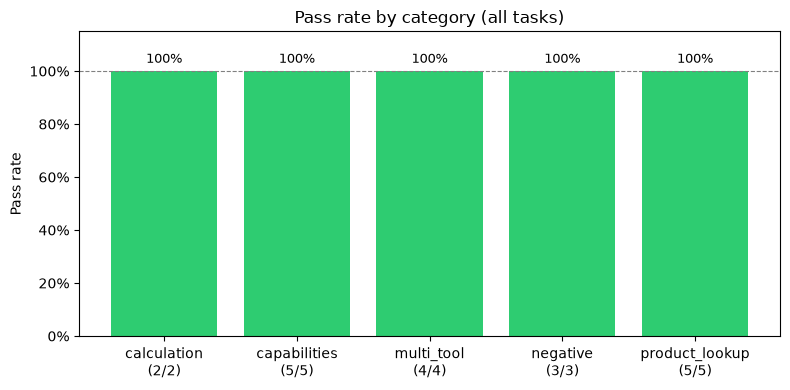

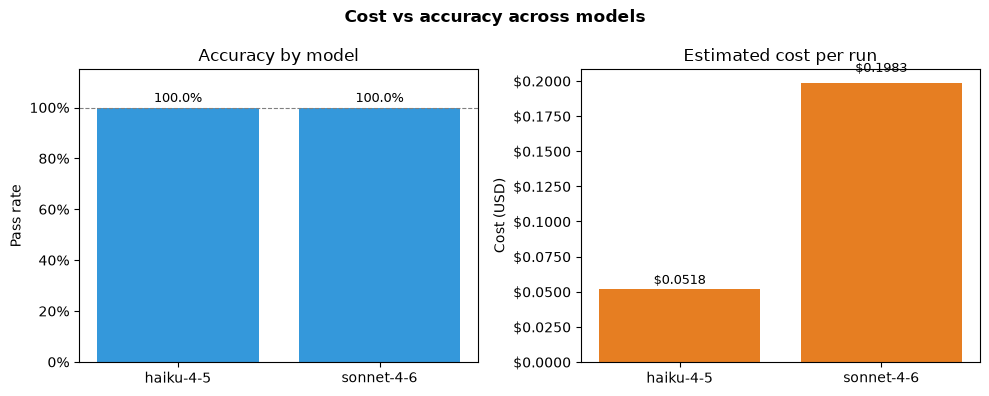

In [30]:
# ── Results visualization ────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def _short_model(model):
    parts = model.split("-")
    return "-".join(p for p in parts[1:] if not (len(p) >= 8 and p.isdigit()))


def plot_category_breakdown(results, title="Pass rate by category"):
    """Bar chart of pass rates per category for the first run in results."""
    run = results["runs"][0]
    cats = {}
    for r in run:
        c = r.get("category", "uncategorized")
        cats.setdefault(c, {"passed": 0, "total": 0})
        cats[c]["total"] += 1
        if r["passed"]:
            cats[c]["passed"] += 1

    names = sorted(cats)
    rates = [100 * cats[c]["passed"] / cats[c]["total"] for c in names]
    labels = [f"{c}\n({cats[c]['passed']}/{cats[c]['total']})" for c in names]
    colors = ["#2ecc71" if r == 100 else "#e74c3c" if r < 60 else "#f39c12" for r in rates]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, rates, color=colors)
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Pass rate")
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{rate:.0f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_model_comparison(rows):
    """Side-by-side bar charts: accuracy (%) and estimated cost (USD) per model."""
    if not rows:
        print("No comparison data — run compare_models() first.")
        return

    labels = [_short_model(r["model"]) for r in rows]
    accs   = [r["pct"]      for r in rows]
    costs  = [r["cost_usd"] for r in rows]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    bars1 = ax1.bar(labels, accs, color="#3498db")
    ax1.set_ylim(0, 115)
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax1.axhline(100, color="gray", linestyle="--", linewidth=0.8)
    ax1.set_title("Accuracy by model")
    ax1.set_ylabel("Pass rate")
    for bar, acc in zip(bars1, accs):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{acc:.1f}%", ha="center", va="bottom", fontsize=9)

    bars2 = ax2.bar(labels, costs, color="#e67e22")
    ax2.set_title("Estimated cost per run")
    ax2.set_ylabel("Cost (USD)")
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.4f"))
    for bar, cost in zip(bars2, costs):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.03,
                 f"${cost:.4f}", ha="center", va="bottom", fontsize=9)

    plt.suptitle("Cost vs accuracy across models", fontweight="bold")
    plt.tight_layout()
    plt.show()


# Category breakdown from the most recent extended eval run
try:
    plot_category_breakdown(results_extended, title="Pass rate by category (all tasks)")
except NameError:
    plot_category_breakdown(results)

# Model comparison (only if compare_models was run)
try:
    plot_model_comparison(model_comparison)
except NameError:
    print("Run the model comparison cell first to see the model chart.")


---

## Extensions

Finished early? Here are ideas ordered roughly by complexity.

### Quick wins
- **Negative test cases.** Queries the agent *should* handle gracefully: "How much is a piano?" (not in catalog), "What's the meaning of life?" (off-topic).
- **Task validation.** Write a function that checks every task dict has the required fields before running the eval.
- **Generate tasks with Claude.** Ask Claude Code to generate additional eval tasks based on the catalog and the patterns you've established.

### Model comparison
- **Haiku vs Sonnet vs Opus.** Run the same eval across models. Does a more capable model compensate for bad tool specs? Use `run_eval(run_agent, tasks, model="claude-sonnet-4–5-20250929")` and compare results.
- **Cost vs accuracy.** Aggregate token usage and estimated cost per run. Is Sonnet worth the extra cost if Haiku passes 90% of tasks?

### Better graders
- **Efficiency graders.** Grade not just correctness but efficiency: did the agent use the minimum number of tool calls?
- **Grader auto-discovery.** Replace the manual `GRADER_REGISTRY` dict with a `@grader` decorator that registers functions automatically.

### Analysis and visualization
- **Results visualization.** Build a chart (matplotlib, plotly) showing pass rates by category or a comparison across models.
- **Baseline comparison.** Diff two saved JSON results side-by-side, flag regressions.
- **Pass@k and pass^k.** Run each task k times. Pass@k = "passed at least once"; pass^k = "passed every time". Useful for distinguishing flaky from reliably broken.
- **Statistical robustness.** Compute variance, confidence intervals, and statistical significance across runs.

### Harness improvements
- **Max turns guard.** Prevent the agent from looping forever by adding a turn limit.
- **Per-task timeouts.** Kill tasks that take too long.
- **Retry with backoff.** Handle transient API errors gracefully.
- **Caching.** Avoid re-running unchanged tasks by hashing the query + agent config.
- **Progress tracking.** Show a live progress bar as the eval runs.
- **Parameter sweep.** Cartesian product over prompts, temperatures, models, etc.

---

## Beyond This Session

### What we simplified

Some design choices in this eval are intentionally simple. Here's what production systems do differently:

- **Agent instrumentation.** We added an `eval_mode` flag so the agent returns the full transcript. In practice, you don't want to modify the agent at all. Production frameworks wrap the agent and intercept API calls to build the transcript without touching agent code.

- **Observability.** We log the full transcript as a flat list. Production systems use OpenTelemetry span trees to capture structured traces with timing, nesting, and metadata, so you can see not just *what* happened but *how long* each step took and how calls were nested.

- **Environment isolation.** Our agent runs in the same process as the eval. For evals that run code (like SWE-bench), a 3-layer Docker pattern is the standard: (1) base image with OS + runtime, (2) environment image with dependencies installed (content-addressable via hash, shared across tasks), (3) instance image with the specific repo checkout per task.

- **Task format.** We use inline Python dicts. Production harnesses typically use JSONL files (one task per line), YAML with references to external files, or database-backed task stores.

### Existing frameworks

You don't have to build an eval harness from scratch. Several frameworks provide this out of the box:

- **Promptfoo.** Open-source eval framework with a nice CLI and web UI.
- **Braintrust.** Hosted eval platform with logging, tracing, and comparison tools.
- **LangSmith.** Tracing and eval platform from the LangChain ecosystem.
- **Harbor.** Open-source eval framework focused on LLM safety.

Internally, Anthropic uses **eval-toolbox** to add evals to our **eval-registry**. A natural follow-up to this session would be migrating your eval to one of these frameworks.